
<div style="text-align: center;">
<h1>The Effect of State Investment in Education</h1>

Joan E. Lambert

College of Computer Science, Western Governors University

D502: Capstone Project for BS Data Analytics
</div>

This Jupyter notebook presents the exploratory data analysis, statistical modeling, and interpretation for this Capstone project.

## Contents

- [1. Environment Setup](#1-environment-setup)
    - [1.1 Import and Configure Libraries](#11-import-and-configure-libraries)
    - [1.2 Load the Data](#12-load-the-data)
- [2. Exploratory Data Analysis](#2-exploratory-data-analysis)
    - [2.1 Descriptive Statistics](#21-descriptive-statistics)
    - [2.2 Variable Distribution](#22-variable-distribution)
    - [2.3 Variable Correlation](#23-variable-correlation)
    - [2.4 Multicollinearity Diagnostics](#24-multicollinearity-diagnostics)
    - [2.5 Temporal Trends](#25-temporal-trends)
    - [2.6 Naive Correlation](#26-naive-correlation)
- [3. Statistical Modeling](#3-statistical-modeling)
    - [3.1 Model Specification](#31-model-specification)
    - [3.2 Fixed-Panel Regression](#32-fixed-panel-regression)
    - [3.3 Specific Regression Results](#33-specific-regression-results)
- [4. Methodological Pivot](#4-methodological-pivot)
    - [4.1 Reasoning](#41-reasoning)
    - [4.2 Revised Approach](#42-revised-approach-cross-sectional-analysis-of-state-averages)
- [5. Additional Data Preparation](#5-additional-data-preparation)
- [6. Additional EDA](#6-additional-eda)
    - [6.1 New Descriptive Statistics](#61-new-descriptive-statistics)
    - [6.2 New Variable Correlation Analysis](#62-new-variable-correlation-analysis)
    - [6.3 New Multicollinearity Ananlysis](#63-new-multicollinearity-analysis)
    - [6.4 New Naive Correlation](#64-new-naive-correlation)
    - [6.5 Comparison of Top and Bottom States](#65-comparison-of-top-and-bottom-states)
- [7. Additional Statistical Modeling](#7-additional-statistical-modeling)
    - [7.1 New Model Specification](#71-new-model-specification)
    - [7.2 Cross-Sectional Analysis of State Averages](#72-cross-sectional-analysis-of-state-averages)
    - [7.3 Robustness Checks](#73-robustness-checks)
- [8. Interpretation and Discussion](#8Interpretation-and-Discussion)
- [9. Limitations](#9Limitations)
    - [9.1 Data and Measurement Limitations](#91-data-and-measurement-limitations)
    - [9.2 Methodological Constraints](#92-methodological-constraints)
- [10. Conclusions](#10Conclusions)
    - [10.1 Key Takeaways](#101-key-takeaways)
    - [10.2 Future Research Ideas](#102-future-research-ideas)
    - [10.3 Final Reflections](#103-final-reflections)

## 1. Environment Setup

### 1.1 Import and Configure Libraries

First we'll import the libraries and elements necessary to conduct the EDA and statistical modeling processes.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

✓ All required packages imported successfully!


Next, we'll set the data display and modeling options.

In [ ]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### 1.2 Load the Data
Finally, we'll load the data.

This project uses data from the following sources:
1.	NCES Digest of Education Statistics, Table 219.46: Public high school graduation rates
2.	NCES Digest of Education Statistics, Table 236.65: Per-pupil expenditure
3.	US Census Bureau American Community Survey, Table B17001: Poverty status
4.	US Census Bureau American Community Survey, Table B19013: Median household income

I manually downloaded the NCES data in Excel file format and retrieved the Census Bureau data by using an API, resulting in these original datasets:

- `data/raw/acs_state_panel.csv`
- `data/raw/tabn219.46.xls`
- `data/raw/tabn236.65.xlsx`

I processed the Excel file data into two CSV files:
- `data/raw/nces_graduation.csv`
- `data/raw/nces_spending.csv`

 I merged the three CSV files into a single panel dataset:
 - `data/processed/merged_panel.csv`

Finally, I adjusted the dollar values in the merged dataset to 2019 dollars, resulting in the file with which we'll perform EDA:
- `data/processed/final_panel.csv`

The data preparation was performed by using the following data acquisition and cleaning scripts:
- `src/pull_acs_data.py` - Census Bureau API data retrieval
- `src/process_nces_data.py` - NCES Excel file processing
- `src/merge_datasets.py` - Dataset merging
- `src/adjust_inflation.py` - CPI adjustment to 2019 dollars

The final dataset contains 500 state-year observations (50 states × 10 years). Nine graduation values are missing from the original source.

In [ ]:
# Load final cleaned and merged dataset
df = pd.read_csv('../data/processed/final_panel.csv')


Loaded 500 observations


,year,state_fips,state_name,graduation_rate,per_pupil_spending,per_pupil_spending_2019,median_hh_income,median_hh_income_2019,poverty_rate,poverty_population,poverty_below
0,2010,1,Alabama,72.0,8725.97,10230.65,40474.0,47453.23,19.03,4666970,888290
1,2011,1,Alabama,75.0,8576.87,9748.14,41415.0,47070.69,19.04,4687363,892483
2,2012,1,Alabama,80.0,8772.54,9768.38,41574.0,46293.39,18.96,4706978,892564
3,2013,1,Alabama,86.3,9036.17,9916.68,42849.0,47024.33,18.73,4716105,883371
4,2014,1,Alabama,89.3,9146.46,9877.49,42830.0,46253.17,19.25,4727549,910175


In [ ]:
# Display first few rows of the dataframe to confirm successful loading
df.head()

,year,state_fips,state_name,graduation_rate,per_pupil_spending,per_pupil_spending_2019,median_hh_income,median_hh_income_2019,poverty_rate,poverty_population,poverty_below
0,2010,1,Alabama,72.0,8725.97,10230.65,40474.0,47453.23,19.03,4666970,888290
1,2011,1,Alabama,75.0,8576.87,9748.14,41415.0,47070.69,19.04,4687363,892483
2,2012,1,Alabama,80.0,8772.54,9768.38,41574.0,46293.39,18.96,4706978,892564
3,2013,1,Alabama,86.3,9036.17,9916.68,42849.0,47024.33,18.73,4716105,883371
4,2014,1,Alabama,89.3,9146.46,9877.49,42830.0,46253.17,19.25,4727549,910175


## 2. Exploratory Data Analysis

### 2.1 Descriptive Statistics

Descriptive statistics provide an overview of the size and shape of the dataframe, and values within the dataframe.

In [36]:
# Basic dataset info
print("Dataset Overview")
print("="*70)
print(f"Shape: {df.shape}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"States: {df['state_name'].nunique()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Descriptive statistics for the variables
print("\nDescriptive Statistics")
print("="*70)
desc_stats = df[['graduation_rate', 'per_pupil_spending_2019', 
                 'median_hh_income_2019', 'poverty_rate']].describe()
print(desc_stats.round(2))

Dataset Overview
Shape: (500, 11)
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
States: 50

Missing values:
year                       0
state_fips                 0
state_name                 0
graduation_rate            9
per_pupil_spending         0
per_pupil_spending_2019    0
median_hh_income           0
median_hh_income_2019      0
poverty_rate               0
poverty_population         0
poverty_below              0
dtype: int64

Descriptive Statistics
       graduation_rate  per_pupil_spending_2019  median_hh_income_2019  \
count           491.00                   500.00                 500.00   
mean             83.22                 12989.70               60192.39   
std               5.47                  3702.71               10126.44   
min              62.00                  7162.37               41305.94   
25%              80.00                 10311

#### Interpretation

The descriptive statistics indicate that the dataframe contains 500 rows and 11 columns (in addition to the index). The data is for 50 states, from the years 2010-2019.

Nine graduation rate statistics are missing from the dataset. Based on the 491 graduation rate statistics, the average graduation rate across all years and states ranges from 62-92.1%, with an average of 83.2%. 75% of the graduation statistics are 80% and above.

Per-pupil spending ranges from $3,702-25,332 with an average of $12,989. Median household income ranges from $41,305-86,738 with an average of $60,192. The poverty rate ranges from 7.3-24.2%, with an average of 14.1%. For all three of these indicators, the top 25% of results appear to be widely separated from the bottom 75% and may include outliers.

### 2.2 Variable Distribution

Distribution plots of the independent, dependent, and control variables visually indicate the distribution of the variable values provided by the descriptive statistics.

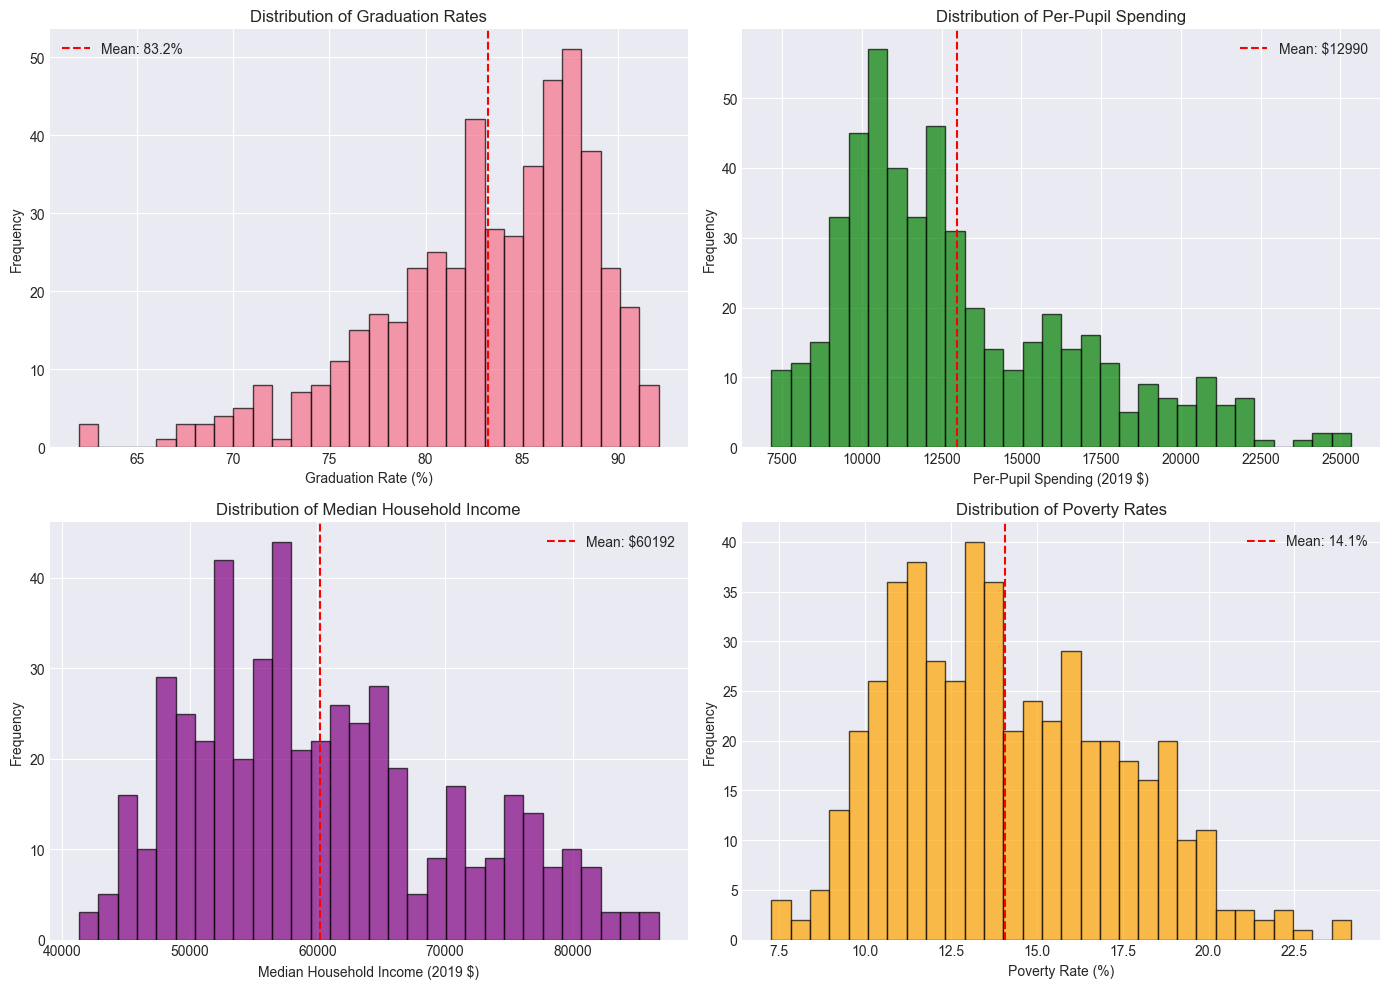

In [7]:
# Distribution of key variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graduation Rate
axes[0, 0].hist(df['graduation_rate'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Graduation Rate (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Graduation Rates')
axes[0, 0].axvline(df['graduation_rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["graduation_rate"].mean():.1f}%')
axes[0, 0].legend()

# Per-Pupil Spending
axes[0, 1].hist(df['per_pupil_spending_2019'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Per-Pupil Spending (2019 $)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Per-Pupil Spending')
axes[0, 1].axvline(df['per_pupil_spending_2019'].mean(), color='red', linestyle='--', label=f'Mean: ${df["per_pupil_spending_2019"].mean():.0f}')
axes[0, 1].legend()

# Median Household Income
axes[1, 0].hist(df['median_hh_income_2019'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('Median Household Income (2019 $)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Median Household Income')
axes[1, 0].axvline(df['median_hh_income_2019'].mean(), color='red', linestyle='--', label=f'Mean: ${df["median_hh_income_2019"].mean():.0f}')
axes[1, 0].legend()

# Poverty Rate
axes[1, 1].hist(df['poverty_rate'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Poverty Rate (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Poverty Rates')
axes[1, 1].axvline(df['poverty_rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["poverty_rate"].mean():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#### Interpretation

This visual representation of the descriptive statistics provided in the previous analysis is helpful to us in confirming the suspected outliers, such as those at the low end of the graduation rate and the high ends of the per-pupil spending and poverty rates.

### 2.3 Variable Correlation

A correlation matrix indicates the correlation rate between each variable and each other variable. The heat map visually indicates the positive or negative values within the range. Red indicates a 1.0 correlation, fading through white at 0 correlation, to blue at -0.75 correlation.

Correlation rates are interpreted as follows:
- 0.00 to ±0.19: Very weak
- ±0.20 to ±0.39: Weak
- ±0.40 to ±0.59: Moderate
- ±0.60 to ±0.79: Strong
- ±0.80 to ±1.00: Very strong

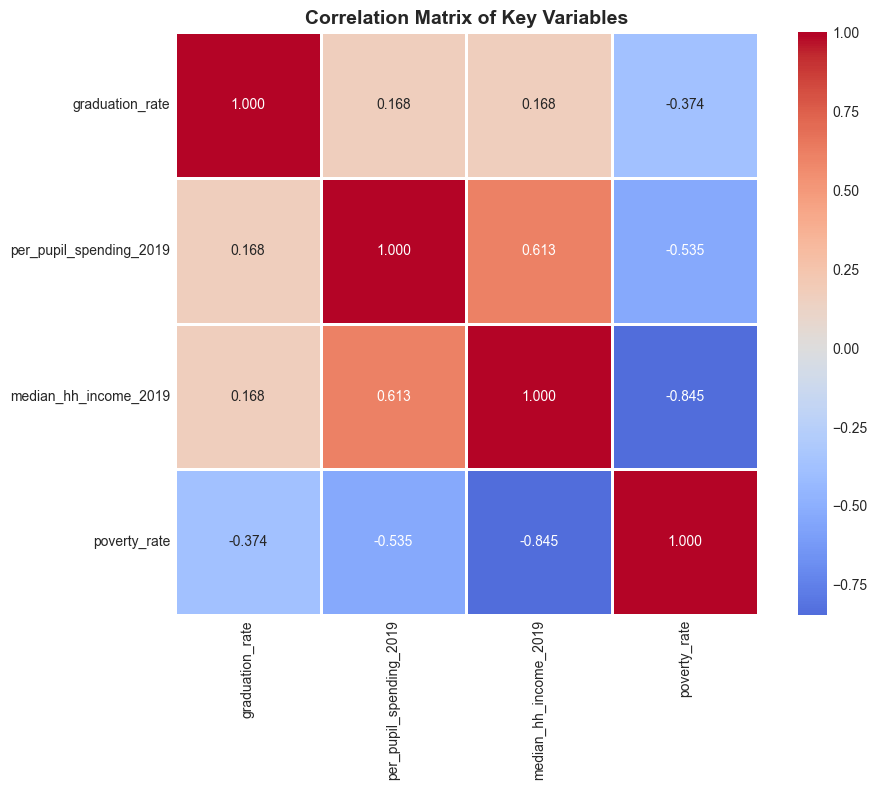


Correlation Matrix:
                         graduation_rate  per_pupil_spending_2019  \
graduation_rate                     1.00                     0.17   
per_pupil_spending_2019             0.17                     1.00   
median_hh_income_2019               0.17                     0.61   
poverty_rate                       -0.37                    -0.54   

                         median_hh_income_2019  poverty_rate  
graduation_rate                           0.17         -0.37  
per_pupil_spending_2019                   0.61         -0.54  
median_hh_income_2019                     1.00         -0.84  
poverty_rate                             -0.84          1.00  


In [ ]:
# Select variables for correlation analysis
corr_vars = ['graduation_rate', 'per_pupil_spending_2019', 
             'median_hh_income_2019', 'poverty_rate']

# Calculate correlation matrix
corr_matrix = df[corr_vars].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Rates within the Matrix:")
print(corr_matrix.round(3))

#### Interpretation

The correlation matrix indicates that across all states and years, per-pupil spending and median household income have the same strength of correlation (0.168) with the graduation rate, and a high correlation (0.61) with each other. This doesn't necessarily mean that they have the same effect on the graduation rate. 0.168 is considered a very weak correlation, which might quickly disprove my hypothesis. This statistic might change when we look at the within-state trends after the fixed effect regression.

Per-pupil spending has a similarly high correlation (0.61) with median household income. As expected, higher-income areas contribute more to public schools, likely through property taxes.

Logically, median household income and poverty rate have a very strong negative correlation (-0.84), indicating that these values move in opposite directions at close to the same rate. Both of these control variables are indicators of economic well-being. Given their very strong negative correlation, including both in the regression might distort the model.

### 2.4 Multicollinearity Diagnostics

The Variance Inflation Factor (VIF) measures multicollinearity between independent variables, indicating whether variables with a high correlation are sufficiently independent of each other to contribute to the data analysis.

Variance Inflation Factors are interpreted as follows:
- VIF < 5 indicates acceptable multicollinearity
- VIF 5-10 indicates moderate multicollinearity
- VIF > 10 indicates high multicollinearity

In [ ]:
# Prepare data for VIF (drop rows with missing graduation_rate)
df_complete = df.dropna(subset=['graduation_rate'])

# Select independent variables
X = df_complete[['per_pupil_spending_2019', 'median_hh_income_2019', 'poverty_rate']]

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nVariance Inflation Factors (VIF)")
print("="*70)
print(vif_data)


Variance Inflation Factors (VIF)
                  Variable    VIF
0  per_pupil_spending_2019  21.43
1    median_hh_income_2019  28.58
2             poverty_rate   7.42


#### Interpretation

A VIF above 10 indicates high multicollinearity, so the VIF values for per-pupil spending and median household income are VERY high--severe and astronomical. Per-pupil spending is our independent variable and must be kept, but median household income should be dropped. This is okay as the poverty rate is a standard socioeconomic control variable, and the state and year fixed effects will control for many other variable conditions.

We'll drop the median income variable and repeat the VIF analysis.

#### Multicollinearity Reanalysis with Variable Adjustments


In [10]:
# Select independent variables
X = df_complete[['per_pupil_spending_2019', 'poverty_rate']]

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nVariance Inflation Factors (VIF)")
print("="*70)
print(vif_data)


Variance Inflation Factors (VIF)
                  Variable   VIF
0  per_pupil_spending_2019  5.56
1             poverty_rate  5.56


##### Interpretation

Both remaining variables have a VIF of 5.56, which is just above the Acceptable level. Poverty level is an important socioeconomic indicator, so I will keep it.

### 2.5 Temporal Trends

A Time Series Visualization of the independent and dependent variables (per-pupil spending and graduation rate) plots each variable over the given years, using primary and secondary y-axes. This provides a comparison of each variable's movement over time.

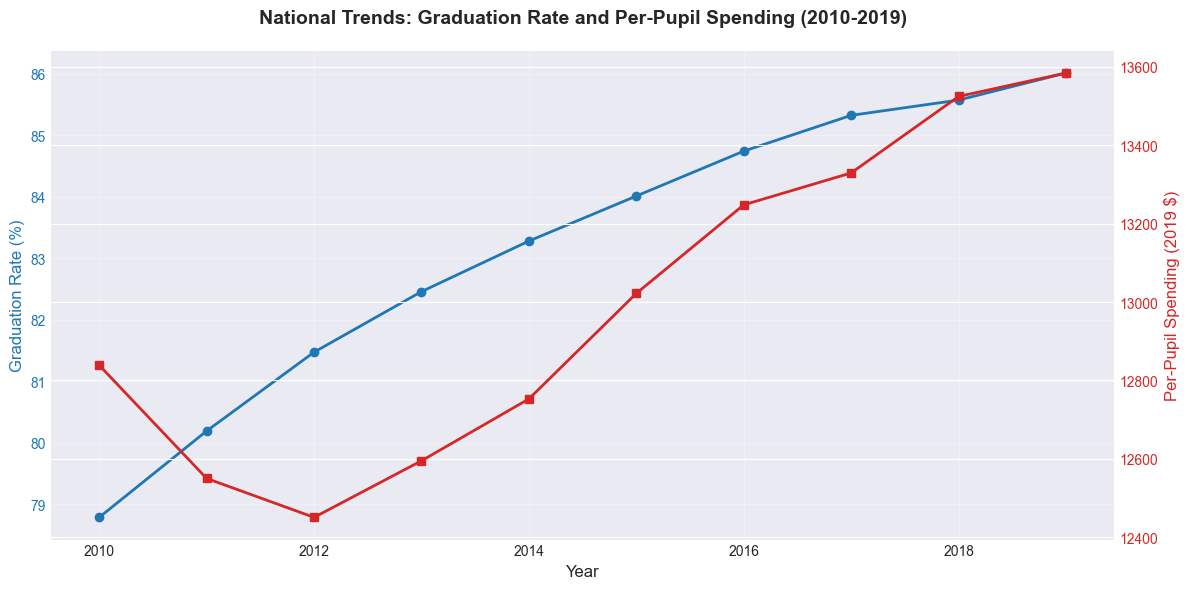

In [11]:
# Average graduation rate and spending over time
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot graduation rate
color = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Graduation Rate (%)', color=color, fontsize=12)
yearly_grad = df.groupby('year')['graduation_rate'].mean()
ax1.plot(yearly_grad.index, yearly_grad.values, color=color, marker='o', linewidth=2, label='Graduation Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot spending on secondary axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Per-Pupil Spending (2019 $)', color=color, fontsize=12)
yearly_spend = df.groupby('year')['per_pupil_spending_2019'].mean()
ax2.plot(yearly_spend.index, yearly_spend.values, color=color, marker='s', linewidth=2, label='Per-Pupil Spending')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('National Trends: Graduation Rate and Per-Pupil Spending (2010-2019)', 
          fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

#### Interpretation

The time series visualization indicates that, across all states, graduation rate rose from 2010-2019, logically slowing each year as it approached 100%. Per-pupil spending fell significantly from 2010-2012 and then rose through 2019, with the spending rate increasing at a higher rate from 2014-2016 and 2017-2018. It will be interesting to see the effect of the year effect regression on the spending rate.

### 2.6 Naive Correlation

A scatter plot and trend line will indicate the naive correlation between the independent and dependent variables before the fixed effects regression.

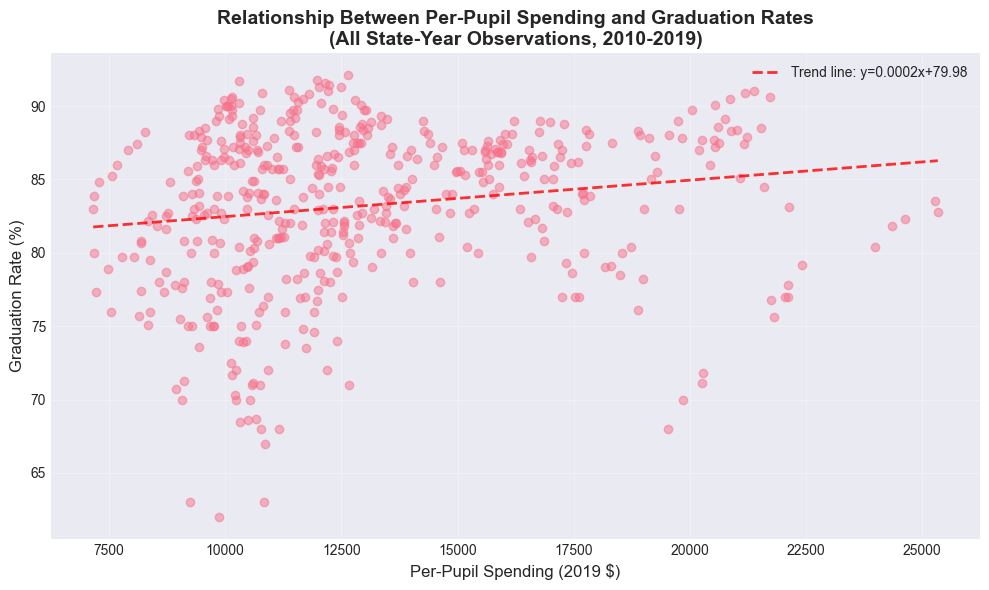

In [12]:
# Create scatter plot
plt.figure(figsize=(10, 6))

# Remove rows with missing values in either variable
df_clean = df.dropna(subset=['per_pupil_spending_2019', 'graduation_rate'])

# Create scatter plot
plt.scatter(df_clean['per_pupil_spending_2019'], df_clean['graduation_rate'], alpha=0.5)

# Add trend line
z = np.polyfit(df_clean['per_pupil_spending_2019'], df_clean['graduation_rate'], 1)
p = np.poly1d(z)
plt.plot(df_clean['per_pupil_spending_2019'].sort_values(), 
         p(df_clean['per_pupil_spending_2019'].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend line: y={z[0]:.4f}x+{z[1]:.2f}')

plt.xlabel('Per-Pupil Spending (2019 $)', fontsize=12)
plt.ylabel('Graduation Rate (%)', fontsize=12)
plt.title('Relationship Between Per-Pupil Spending and Graduation Rates\n(All State-Year Observations, 2010-2019)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation

The trend line indicates a very weak correlation (0.0002) between the per-pupil spend and graduation rate. This is in line with the very weak correlation rate indicated in the Correlation Matrix, and will serve as an excellent indicator of the state and year fixed effects after the regression.

## 3. Statistical Modeling

### 3.1 Model Specification

The analysis uses a two-way fixed effects panel regression model to estimate the relationship between per-pupil spending and high school graduation rates:

$$GraduationRate_{it} = \beta_1 \cdot PerPupilSpending_{it} + \beta_2 \cdot PovertyRate_{it} + \alpha_i + \delta_t + \epsilon_{it}$$

Where:
- $i$ indexes states (1 to 50)
- $t$ indexes years (2010 to 2019)
- $\alpha_i$ represents state fixed effects (controls for time-invariant state characteristics)
- $\delta_t$ represents year fixed effects (controls for national trends)
- $\epsilon_{it}$ is the error term

Key features of the model are as follows:
- Dependent variable: Public high school graduation rate
- Independent variable: Per-pupil spending (constant 2019 dollars)
- Control variable: Poverty rate
- Fixed effects: State and year
- Standard errors: Clustered at the state level to account for within-state correlation

The model isolates within-state variation over time, effectively asking: "When a state increases spending relative to its historical average, does its graduation rate improve?"

### 3.2 Fixed-Panel Regression

In [ ]:
# Drop observations with missing graduation rate
df_reg = df.dropna(subset=['graduation_rate']).copy()

print(f"Observations with complete data: {len(df_reg)}")
print(f"States: {df_reg['state_name'].nunique()}")
print(f"Years: {sorted(df_reg['year'].unique())}")

# Create two-level index for linearmodels
df_reg = df_reg.set_index(['state_name', 'year'])

# Verify no missing values in key variables
print(f"\nMissing values in regression variables:")
print(df_reg[['graduation_rate', 'per_pupil_spending_2019', 'poverty_rate']].isnull().sum())

Preparing data for panel regression...
Observations with complete data: 491
States: 50
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]

Missing values in regression variables:
graduation_rate            0
per_pupil_spending_2019    0
poverty_rate               0
dtype: int64


In [ ]:
# Run two-way fixed effects regression

# Define dependent and independent variables
y = df_reg['graduation_rate']
X = df_reg[['per_pupil_spending_2019', 'poverty_rate']]

# Add constant (though fixed effects absorb it)
X = sm.add_constant(X)

# Estimate two-way fixed effects model with clustered standard errors
model = PanelOLS(y, X, entity_effects=True, time_effects=True)
results = model.fit(cov_type='clustered', cluster_entity=True)

# Display results
print("="*70)
print("TWO-WAY FIXED EFFECTS REGRESSION RESULTS")
print("="*70)
print("")
print(results)

TWO-WAY FIXED EFFECTS REGRESSION RESULTS

                          PanelOLS Estimation Summary                           
Dep. Variable:        graduation_rate   R-squared:                        0.0447
Estimator:                   PanelOLS   R-squared (Between):             -0.1172
No. Observations:                 491   R-squared (Within):               0.1350
Date:                Fri, Mar 13 2026   R-squared (Overall):             -0.0329
Time:                        11:23:06   Log-likelihood                   -1014.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.057
Entities:                          50   P-value                           0.0001
Avg Obs:                       9.8200   Distribution:                   F(2,430)
Min Obs:                       7.0000                                           
Max Obs:                      10.0000   F-statistic (robust):      

### 3.3 Key Findings of Regression

In [ ]:
# Extract key statistics
coef_spending = results.params['per_pupil_spending_2019']
se_spending = results.std_errors['per_pupil_spending_2019']
pval_spending = results.pvalues['per_pupil_spending_2019']
ci_lower = results.conf_int().loc['per_pupil_spending_2019', 'lower']
ci_upper = results.conf_int().loc['per_pupil_spending_2019', 'upper']

print("\nKey Findings:")
print("="*70)
print(f"Coefficient on per-pupil spending: {coef_spending:.6f}")
print(f"Standard error: {se_spending:.6f}")
print(f"P-value: {pval_spending:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"\nStatistical significance: {'Yes' if pval_spending < 0.05 else 'No'} at α = 0.05")

# Calculate effect size
effect_per_1000 = coef_spending * 1000
print(f"\nEffect size interpretation:")
print(f"A $1,000 increase in per-pupil spending is associated with a")
print(f"{effect_per_1000:.3f} percentage point change in graduation rate.")

# R-squared
print(f"\nModel fit:")
print(f"R-squared (overall): {results.rsquared:.4f}")
print(f"R-squared (within): {results.rsquared_within:.4f}")
print(f"R-squared (between): {results.rsquared_between:.4f}")


KEY FINDINGS:
Coefficient on per-pupil spending: -0.000598
Standard error: 0.000393
P-value: 0.1286
95% Confidence Interval: [-0.001370, 0.000174]

Statistical significance: No at α = 0.05

Effect size interpretation:
A $1,000 increase in per-pupil spending is associated with a
-0.598 percentage point change in graduation rate.

Model fit:
R-squared (overall): 0.0447
R-squared (within): 0.1350
R-squared (between): -0.1172


#### Interpretation

These are certainly not the results I was expecting. And at this point I realize that the model I chose is comparing current-year spending to current-year graduation rates, and OF COURSE there is no effect.

I think I need to start over.

## 4. Methodological Pivot

### 4.1 Reasoning
The panel regression approach produced insignificant results with unexpected negative coefficients. Upon seeing these results, I realized a fundamental issue in the logic of the approach: current-year spending will almost certainly not affect current-year graduation rates. Students generally attend 13 years of public school (Kindergarten through 12th grade). Benefits in any one year would not affect eventual graduation rates; this would require a sustained level of investment.

### 4.2 Revised Approach

To address this limitation, I'm reframing the analysis of the cleaned and merged data that we already have as a cross-sectional comparison of state averages (2010-2019). Using this modified approach, we will look at whether, when normalized for state-specific socioeconomic conditions, states that spend more per-pupil have better graduation rates than states that spend less.

The updated hypothesis is, "States with higher average per-pupil spending from 2010-2019 have higher graduation rates over the same period, after controlling for socioeconomic factors."

## 5. Additional Data Preparation

The data gathering, cleaning, and merging done for the fixed-panel regression analysis is valid for the cross-sectional analysis. We need only to create a dataframe that aggregates the original data by state.

In [ ]:
# Create state-level averages for 2010-2019
state_averages = df.groupby('state_name').agg({
    'graduation_rate': 'mean',
    'per_pupil_spending_2019': 'mean',
    'poverty_rate': 'mean',
    'median_hh_income_2019': 'mean'
}).reset_index()

# Rename columns for clarity
state_averages.columns = [
    'state_name',
    'avg_graduation_rate',
    'avg_per_pupil_spending',
    'avg_poverty_rate',
    'avg_median_income'
]

# Display first few rows of the state-level dataset
print(f"\nSample:")
print(state_averages.head())

# Check for missing values
print(f"\nMissing values:")
print(state_averages.isnull().sum())


Sample:
   state_name  avg_graduation_rate  avg_per_pupil_spending  avg_poverty_rate  \
0     Alabama                85.13                10024.01             17.98   
1      Alaska                74.88                19516.83             10.34   
2     Arizona                77.35                 8552.81             16.80   
3    Arkansas                86.23                10679.20             18.28   
4  California                81.59                11961.01             15.02   

   avg_median_income  
0           48434.37  
1           77280.86  
2           56248.62  
3           45987.72  
4           70435.78  

Missing values:
state_name                0
avg_graduation_rate       0
avg_per_pupil_spending    0
avg_poverty_rate          0
avg_median_income         0
dtype: int64


## 6. Additional EDA

### 6.1 New Descriptive Statistics



In [24]:
print("Descriptive Statistics: State Averages (2010-2019)")
print("="*70)
desc_stats = state_averages[['avg_graduation_rate', 'avg_per_pupil_spending', 
                              'avg_poverty_rate', 'avg_median_income']].describe()
print(desc_stats.round(2))

Descriptive Statistics: State Averages (2010-2019)
       avg_graduation_rate  avg_per_pupil_spending  avg_poverty_rate  \
count                50.00                   50.00             50.00   
mean                 83.24                12989.70             14.07   
std                   4.59                 3677.29              3.01   
min                  70.84                 7587.72              8.31   
25%                  79.98                10448.54             11.56   
50%                  84.56                12058.41             13.91   
75%                  86.69                15289.92             16.34   
max                  90.51                23397.94             21.65   

       avg_median_income  
count              50.00  
mean            60192.39  
std              9817.45  
min             43596.72  
25%             53260.00  
50%             58710.81  
75%             67511.36  
max             82055.68  


#### Interpretation
The aggregated dataset contains 50 records, one per state. No data is missing. Each variable has a very wide range of values, with average graduation rates from 70-90%, average spending from $7,500-24,000; average poverty rates from 8-22%, and average median income from $44-82,000.

For each state, there is a more-significant increase between the 75% and maximum values than in any other quartile. This seems to indicate that there is at least one significant outlier in each or all categories.

### 6.2 New Variable Correlation Analysis
A correlation matrix indicates the correlation rate between each variable and each other variable. The heat map visually indicates the positive or negative values within the range. Red indicates a 1.0 correlation, fading through white at 0 correlation, to blue at -0.75 correlation.

Correlation rates are interpreted as follows:
- 0.00 to ±0.19: Very weak
- ±0.20 to ±0.39: Weak
- ±0.40 to ±0.59: Moderate
- ±0.60 to ±0.79: Strong
- ±0.80 to ±1.00: Very strong

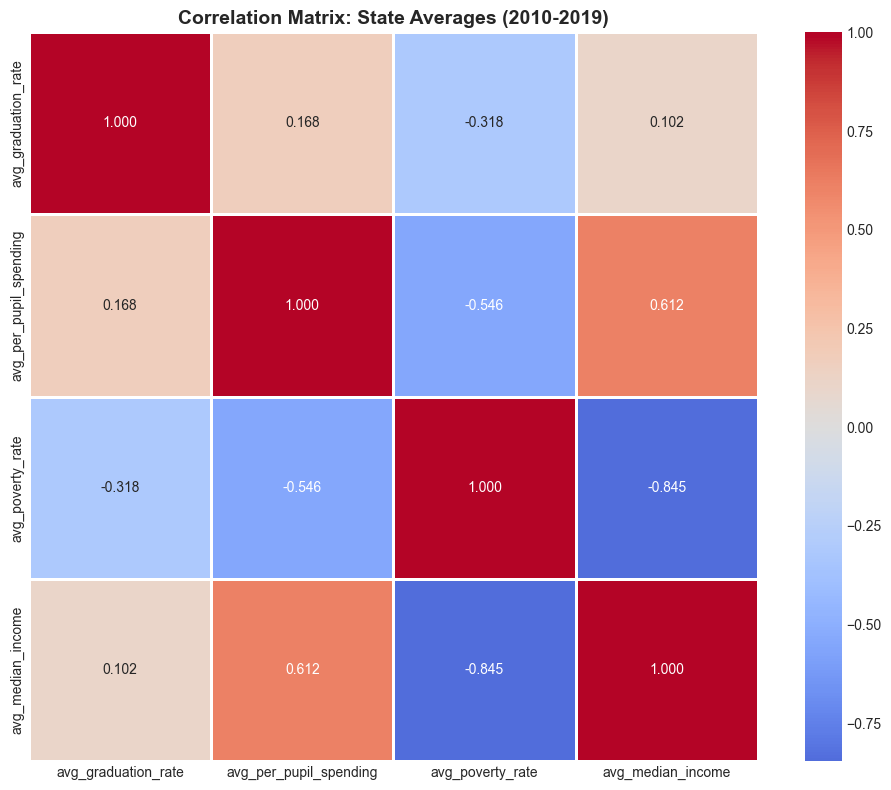


Correlation Matrix (State Averages):
                        avg_graduation_rate  avg_per_pupil_spending  \
avg_graduation_rate                    1.00                    0.17   
avg_per_pupil_spending                 0.17                    1.00   
avg_poverty_rate                      -0.32                   -0.55   
avg_median_income                      0.10                    0.61   

                        avg_poverty_rate  avg_median_income  
avg_graduation_rate                -0.32               0.10  
avg_per_pupil_spending             -0.55               0.61  
avg_poverty_rate                    1.00              -0.84  
avg_median_income                  -0.84               1.00  


In [25]:
# Correlation matrix for state averages
corr_vars = ['avg_graduation_rate', 'avg_per_pupil_spending', 
             'avg_poverty_rate', 'avg_median_income']

corr_matrix_states = state_averages[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_states, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix: State Averages (2010-2019)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix (State Averages):")
print(corr_matrix_states.round(3))

#### Interpretation

The correlation matrix of the state_averages dataframe is very similar to the original correlation matrix created in [Section 2.3](#23-variable-correlation).

As in the original analysis, per-pupil spending has a very weak (0.168) correlation with the graduation rate and median income has a very strong (-0.84) negative correlation with poverty. These statistics have not changed.

When comparing state averages, we see slightly lower levels of correlation between graduation rates and both poverty rate and median income. Correlation with median income decreased from 0.17 to 0.10, and correlation with poverty rate decreased from -0.37 to -0.32.

### 6.3 New Multicollinearity Analysis

The Variance Inflation Factor (VIF) measures multicollinearity between independent variables, indicating whether variables with a high correlation are sufficiently independent of each other to contribute to the data analysis.

Variance Inflation Factors are interpreted as follows:
- VIF < 5 indicates acceptable multicollinearity
- VIF 5-10 indicates moderate multicollinearity
- VIF > 10 indicates high multicollinearity

In [26]:
# VIF for state-level cross-sectional model
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_states = state_averages[['avg_per_pupil_spending', 'avg_poverty_rate']].dropna()

vif_data_states = pd.DataFrame()
vif_data_states['Variable'] = X_states.columns
vif_data_states['VIF'] = [variance_inflation_factor(X_states.values, i) 
                           for i in range(len(X_states.columns))]

print("\nVariance Inflation Factors (State Averages)")
print("="*70)
print(vif_data_states)


Variance Inflation Factors (State Averages)
                 Variable   VIF
0  avg_per_pupil_spending  5.91
1        avg_poverty_rate  5.91


#### Interpretation
The multicollinearity between the independent and control variables has increased slightly from the [original analysis](#multicollinearity-reanalysis-with-variable-adjustments), from 5.56 to 5.91.

### 6.4 New Naive Correlation
A scatter plot and trend line will indicate the naive correlation between the independent and dependent variables before accounting for poverty rate.

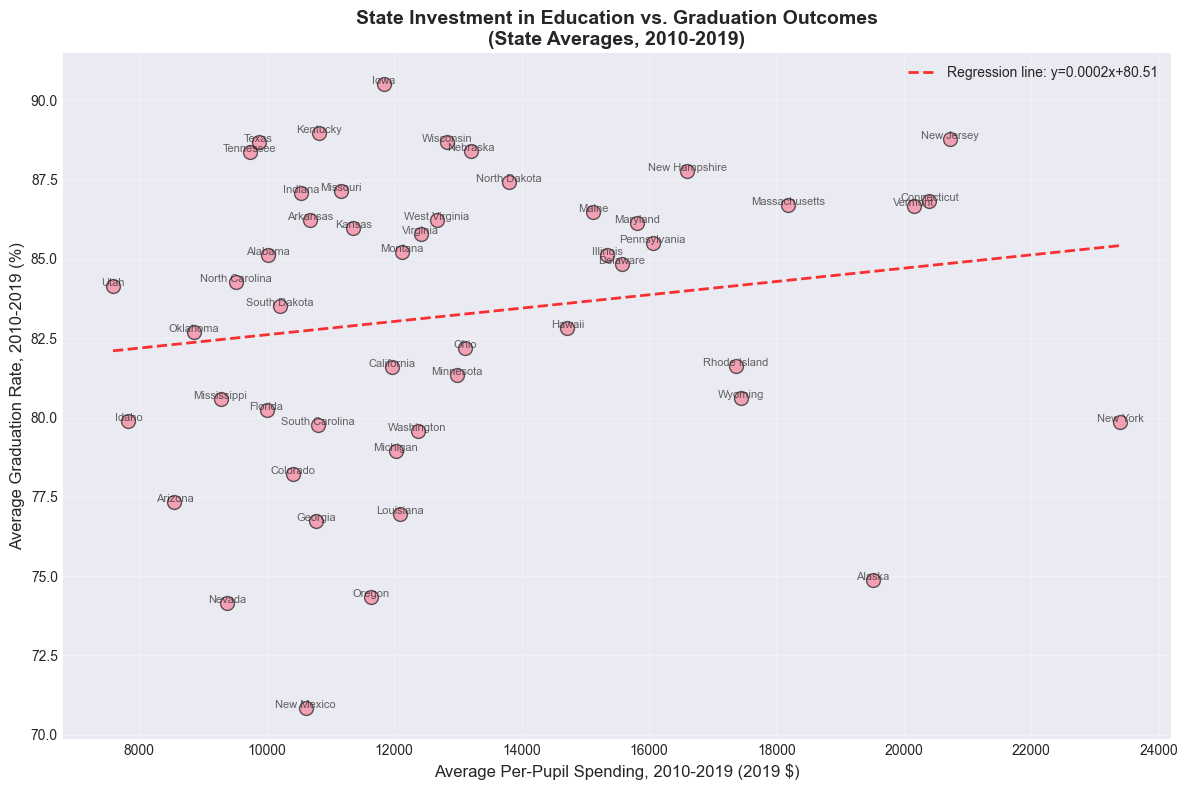

In [27]:
# Scatter plot with state labels
plt.figure(figsize=(12, 8))

# Scatter points
plt.scatter(state_averages['avg_per_pupil_spending'], 
           state_averages['avg_graduation_rate'], 
           s=100, alpha=0.6, edgecolors='black', linewidth=1)

# Add state labels
for idx, row in state_averages.iterrows():
    plt.annotate(row['state_name'], 
                (row['avg_per_pupil_spending'], row['avg_graduation_rate']),
                fontsize=8, alpha=0.7, ha='center')

# Add regression line
z = np.polyfit(state_averages['avg_per_pupil_spending'].dropna(), 
               state_averages.dropna(subset=['avg_per_pupil_spending', 'avg_graduation_rate'])['avg_graduation_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(state_averages['avg_per_pupil_spending'].min(), 
                     state_averages['avg_per_pupil_spending'].max(), 100)
plt.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, 
         label=f'Regression line: y={z[0]:.4f}x+{z[1]:.2f}')

plt.xlabel('Average Per-Pupil Spending, 2010-2019 (2019 $)', fontsize=12)
plt.ylabel('Average Graduation Rate, 2010-2019 (%)', fontsize=12)
plt.title('State Investment in Education vs. Graduation Outcomes\n(State Averages, 2010-2019)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation
The angle of the trendline remains the same, with y=0.0002x, showing a weak correlation between spending and graduation rates before accounting for poverty rates. Because we now have only 50 data points, we can compare the average spending and graduation rates by state. Before accounting for socioeconomic factors, the state with the highest spending (New York) has a below-average rate of graduation and the state with the lowest spending (Utah) has an above-average graduation rate.

### 6.5 Comparison of Top and Bottom States
This analysis provides an easy comparison of graduation rates by spending.

In [28]:
# Show top and bottom states
print("\nTop 10 States by Average Spending:")
print(state_averages.nlargest(10, 'avg_per_pupil_spending')[['state_name', 'avg_per_pupil_spending', 'avg_graduation_rate']])

print("\nBottom 10 States by Average Spending:")
print(state_averages.nsmallest(10, 'avg_per_pupil_spending')[['state_name', 'avg_per_pupil_spending', 'avg_graduation_rate']])


Top 10 States by Average Spending:
       state_name  avg_per_pupil_spending  avg_graduation_rate
31       New York                23397.94                79.86
29     New Jersey                20716.54                88.79
6     Connecticut                20400.97                86.82
44        Vermont                20159.56                86.66
1          Alaska                19516.83                74.88
20  Massachusetts                18186.24                86.70
49        Wyoming                17443.35                80.62
38   Rhode Island                17359.28                81.61
28  New Hampshire                16602.72                87.79
37   Pennsylvania                16055.14                85.51

Bottom 10 States by Average Spending:
        state_name  avg_per_pupil_spending  avg_graduation_rate
43            Utah                 7587.72                84.15
11           Idaho                 7829.19                79.90
2          Arizona                 8552.

#### Interpretation
The graduation rates in the 10 states with the **highest** unadjusted spending range from 74.88-88.79%.
The graduation rates in the 10 states with the **lowest** unadjusted spending range from 74.14-88.68%.

Before accounting for poverty, there is virtually no different in these statistics.


## 7. Additional Statistical Modeling

### 7.1 New Model Specification

This analysis uses a cross-sectional ordinary least squares (OLS) regression to examine the relationship between state-level education investment and graduation outcomes. The model controls for average poverty rate to account for socioeconomic differences between states. This ensures the estimated relationship between spending and graduation rates is not simply reflecting that wealthier states both spend more and have better outcomes for unrelated reasons.

$$AvgGraduationRate_i = \beta_0 + \beta_1 \cdot AvgPerPupilSpending_i + \beta_2 \cdot AvgPovertyRate_i + \epsilon_i$$

Where $i$ indexes states (1 to 50).

All variables represent **average values over the 2010-2019 period**, capturing sustained state investment and outcomes rather than year-to-year fluctuations.

**Rationale:** Single-year spending cannot affect graduation rates for students already in the education pipeline. By averaging over the decade, we compare states based on their sustained commitment to education investment and their overall educational outcomes during this period.

### 7.2 Cross-Sectional Analysis of State Averages

In [ ]:
# Prepare variables
y = state_averages['avg_graduation_rate'].dropna()
X = state_averages[['avg_per_pupil_spending', 'avg_poverty_rate']].dropna()

# Align indices
valid_idx = y.index.intersection(X.index)
y = y.loc[valid_idx]
X = X.loc[valid_idx]

# Add constant
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X)
results = model.fit()

print("="*70)
print("CROSS-SECTIONAL OLS REGRESSION RESULTS")
print("State Averages, 2010-2019")
print("="*70)
print(results.summary())

# Extract key statistics
coef_spending = results.params['avg_per_pupil_spending']
pval_spending = results.pvalues['avg_per_pupil_spending']
ci = results.conf_int().loc['avg_per_pupil_spending']

print("\n" + "="*70)
print("Key Findings")
print("="*70)
print(f"Coefficient on average per-pupil spending: {coef_spending:.6f}")
print(f"P-value: {pval_spending:.4f}")
print(f"95% CI: [{ci[0]:.6f}, {ci[1]:.6f}]")
print(f"Significant at α=0.05: {'Yes' if pval_spending < 0.05 else 'No'}")

# Effect size
effect_per_1000 = coef_spending * 1000
print(f"\nEffect size:")
print(f"A $1,000 higher average spending is associated with")
print(f"a {effect_per_1000:.3f} percentage point difference in average graduation rate.")

CROSS-SECTIONAL OLS REGRESSION RESULTS
State Averages, 2010-2019
                             OLS Regression Results                            
Dep. Variable:     avg_graduation_rate   R-squared:                       0.101
Model:                             OLS   Adj. R-squared:                  0.063
Method:                  Least Squares   F-statistic:                     2.643
Date:                 Thu, 19 Mar 2026   Prob (F-statistic):             0.0817
Time:                         19:11:20   Log-Likelihood:                -143.98
No. Observations:                   50   AIC:                             294.0
Df Residuals:                       47   BIC:                             299.7
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

### 7.3 Robustness Checks

#### Robustness Check 1: Without Control Variable
As previously, this operation checks the effect of including the poverty rate in the equation.

In [30]:
# Model without poverty control
X_nocontrol = state_averages[['avg_per_pupil_spending']].dropna()
X_nocontrol = sm.add_constant(X_nocontrol)

y_aligned = y.loc[X_nocontrol.index]

model_nocontrol = sm.OLS(y_aligned, X_nocontrol)
results_nocontrol = model_nocontrol.fit()

print("Model without poverty control:")
print(results_nocontrol.summary())

Model without poverty control:
                             OLS Regression Results                            
Dep. Variable:     avg_graduation_rate   R-squared:                       0.028
Model:                             OLS   Adj. R-squared:                  0.008
Method:                  Least Squares   F-statistic:                     1.398
Date:                 Thu, 19 Mar 2026   Prob (F-statistic):              0.243
Time:                         19:13:46   Log-Likelihood:                -145.93
No. Observations:                   50   AIC:                             295.9
Df Residuals:                       48   BIC:                             299.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

#### Robustness Check 2: With Alternative Control Variable
In the original model, we dropped median income as a socioeconomic variable because it appeared to have the same effect as poverty and to skew the effect. This operation checks the effect of substituting median income for poverty in the equation.

In [31]:
# Model with median income instead of poverty
X_income = state_averages[['avg_per_pupil_spending', 'avg_median_income']].dropna()
X_income = sm.add_constant(X_income)

y_aligned = y.loc[X_income.index]

model_income = sm.OLS(y_aligned, X_income)
results_income = model_income.fit()

print("Model with median income control:")
print(results_income.summary())

Model with median income control:
                             OLS Regression Results                            
Dep. Variable:     avg_graduation_rate   R-squared:                       0.028
Model:                             OLS   Adj. R-squared:                 -0.013
Method:                  Least Squares   F-statistic:                    0.6845
Date:                 Thu, 19 Mar 2026   Prob (F-statistic):              0.509
Time:                         19:14:07   Log-Likelihood:                -145.93
No. Observations:                   50   AIC:                             297.9
Df Residuals:                       47   BIC:                             303.6
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

#### Robustness Check Comparison

In [38]:
print("Comparison of Models")
print("="*70)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Main Model (with poverty control)',
        'Without poverty control', 
        'With median income control'
    ],
    'Spending Coefficient': [
        coef_spending,
        results_nocontrol.params['avg_per_pupil_spending'],
        results_income.params['avg_per_pupil_spending']
    ],
    'Spending P-value': [
        pval_spending,
        results_nocontrol.pvalues['avg_per_pupil_spending'],
        results_income.pvalues['avg_per_pupil_spending']
    ],
    'R-squared': [
        results.rsquared,
        results_nocontrol.rsquared,
        results_income.rsquared
    ]
})

print("\n")
print(comparison.to_string(index=False))


Comparison of Models


                            Model  Spending Coefficient  Spending P-value  R-squared
Main Model (with poverty control)             -9.33e-06              0.96       0.10
          Without poverty control              2.10e-04              0.24       0.03
       With median income control              2.11e-04              0.36       0.03


#### Interpretation

The robustness checks compared three model specifications:

1. The main model, which controls for average poverty rate
2. An alternative model without a control variable
3. An alternative model with median household income as the control variable


The coefficients of per-pupil spending for all three models are near (from -0.000009 to 0.00021), indicating no meaningful relationship. The p-values for all three models are greater than 0.05, which is another indicator of the insignificance of per-pupil spending.

Additionally, R-squared is low  (3-10%) across all models, suggesting that spending explains virtually none of the variation in graduation rates.


## 8. Interpretation and Discussion
The robustness of this null finding across different model specifications provides strong evidence that state-level education spending did not drive graduation rates during the school year periods from 2010-2019. I'm again surprised at these findings.

The inclusion of socioeconomic controls (poverty or median income) does not materially change the data analysis. While poverty shows marginal explanatory power, spending levels do not systematically predict graduation outcomes, regardless of model specification.

This suggests that factors other than state spending have a greater effect on graduation rates. These might include family support, teacher quality, school culture, or many other factors not considered in this study.


## 9. Limitations

Several limitations should be considered when interpreting these findings.

### 9.1 Data and Measurement Limitations

1. Temporal Alignment: This analysis uses 2010-2019 average spending and graduation rates as a proxy for sustained state investment. Ideally, graduation outcomes would be matched to spending during each year of a student cohort's K-12 experience. However, the decade-average approach provides a reasonable approximation under the assumption that states' relative investment levels were stable over the sample time period.

2. Unmeasured Variables: The analysis controls for poverty but does not account for other factors that likely influence graduation rates, such as:
    - Teacher quality and retention
    - Curriculum rigor and instructional methods
    - School leadership and culture
    - Family engagement and community support
    - State-specific graduation requirements and standards


3. Aggregation Level: State-level analysis masks substantial within-state variation. District-level or school-level analysis might reveal relationships not visible at the state level. It's possible that funding within states is not distributed equally among school districts or schools.

### 9.2 Methodological Constraints

1. Cross-Sectional Design: This analysis compares states to each other rather than tracking changes over time. While this addresses the cohort-timing issue, it cannot establish causation or account for state-specific factors beyond those measured.

2. Missing Graduation Data: Nine state-year observations lacked graduation rate data in the original panel, reducing the available observations for creating state averages.

3. Lack of Spending Categorization: The analysis examines total per-pupil expenditure rather than distinguishing between spending categories such as instruction, administration, buildings, supplies, and tests, among others unknown to this author. Different types of spending may have different effects on outcomes.

## 10. Conclusions

This study examined whether state-level investment in public education is associated with high school graduation outcomes using decade-average data from 2010-2019 for all 50 US states. The analysis found no significant relationship between per-pupil spending and graduation rates, after controlling for poverty.

### 10.1 Key Takeaways

1. The amount of money that a state spends per pupil has no effect on graduation rates.
2. Poverty rate has nearly twice the effect on graduation rates as per-pupil spending. States might see greater effects by allocating money to address economic disadvantages than by increasing per-pupil spending.
3. Other factors are at play: The wide variation in graduation rates among states with similar spending levels, and the wide variation in spending levels among states with similar graduation rates, indicate that factors other than funding are important.

### 10.2 Future Research Ideas

Future studies could strengthen understanding of education funding effectiveness by:
- Examining district-level or school-level data
- Distinguishing between types of spending
- Tracking cohorts of students and matching spending to their specific educational trajectories
- Identifying commonalities between other variables for states that have the highest graduation rates

### 10.3 Final Reflections

This project began with a fixed-panel regression approach that revealed a critical methodological issue: spending does not affect graduation rates in the same year. Pivoting to a cross-sectional analysis model using state averages over the same time period seemed as though it would provide a more appropriate framework. While I believe that this approach more closely aligns the relationship of the independent and dependent variables over time, there was still a null finding. Although disappointing, this evidence indicates to me that improving educational outcomes requires more than financial investment and leaves me to consider new pathways for research into this important topic.

The next step in this process is to create a Tableau dashboard visualizing the data. I'll export the data for that purpose.

In [39]:
# Create clean dataset for Tableau
tableau_data = state_averages[['state_name', 'avg_graduation_rate', 
                                'avg_per_pupil_spending', 'avg_poverty_rate']].copy()

# Rename columns for clarity in Tableau
tableau_data.columns = ['State', 'Avg Graduation Rate (%)', 
                        'Avg Per-Pupil Spending ($)', 'Avg Poverty Rate (%)']

# Round to 2 decimal places for cleaner display
tableau_data = tableau_data.round(2)

# Save to CSV
tableau_data.to_csv('../data/processed/state_averages_for_tableau.csv', index=False)